### 每月销售额总量预测

### Connect postgresql database

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

# 数据库配置
username = "XXXXXX"
password = "YYYYYY"
host = "localhost"
port = 5432
database = "eyewear-data"

# 创建连接
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)


### Query and cal customer RFM feature

In [ ]:
# 1 . 每月销售额、订单数量和平均订单价值
sale_amount_monthly_sql = """
WITH region_monthly_revenue AS (
    SELECT
        TO_CHAR(o.order_date,'YYYY-MM') AS order_month,
        c.region,
        SUM(oi.line_price_after_tax) AS region_revenue
    FROM "Order" o
    JOIN "OrderItem" oi
        ON o.order_id = oi.order_id
    LEFT JOIN "CustomerInfo" c
        ON o.customer_id = c.customer_id
    WHERE o.order_status IN ('Completed','Shipped')
      AND o.order_date IS NOT NULL
      AND oi.line_price_after_tax > 0
    GROUP BY TO_CHAR(o.order_date,'YYYY-MM'), c.region
),

region_rank AS (
    SELECT
        order_month,
        region,
        region_revenue,
        RANK() OVER(PARTITION BY order_month ORDER BY region_revenue DESC) AS region_rank
    FROM region_monthly_revenue
),

region_concentration AS (
    SELECT
        order_month,
        -- 第一大地区收入占比
        MAX(CASE WHEN region_rank = 1 THEN region_revenue END)::numeric / NULLIF(SUM(region_revenue)::numeric,0)
        AS top_region_revenue_ratio,
        -- Top5地区收入占比
        SUM(CASE WHEN region_rank <=5 THEN region_revenue ELSE 0 END)::numeric / NULLIF(SUM(region_revenue)::numeric,0)
        AS top5_region_revenue_ratio
    FROM region_rank
    GROUP BY order_month
),
region_entropy AS (
  SELECT
      order_month,
      -SUM(revenue_share * LN(revenue_share)) AS region_revenue_entropy
  FROM
  (SELECT
      order_month,
      region,
      region_revenue::numeric / SUM(region_revenue::numeric) OVER(PARTITION BY order_month) AS revenue_share
    FROM region_monthly_revenue
  ) t
  GROUP BY order_month
),
region_entropy_change AS (
    SELECT
        order_month,
        region_revenue_entropy,
        region_revenue_entropy - LAG(region_revenue_entropy) OVER(ORDER BY order_month) AS region_entropy_change
    FROM region_entropy
),
region_concentration_change AS (
    SELECT
        order_month,
        top_region_revenue_ratio,
        top5_region_revenue_ratio,
        top5_region_revenue_ratio - LAG(top5_region_revenue_ratio) OVER(ORDER BY order_month) AS top5_region_ratio_change
    FROM region_concentration
)



SELECT
    to_char(o.order_date, 'YYYY-MM') AS order_month,
    -- 基础指标
    COUNT(DISTINCT o.order_id) AS order_count,
    COUNT(DISTINCT o.customer_id) AS unique_customer_count,
    SUM(oi.line_price_after_tax) AS monthly_revenue,           -- 推荐使用税后金额
    SUM(oi.line_price_before_tax) AS monthly_revenue_before_tax,
    SUM(o.total_price_after_tax)/COUNT(DISTINCT o.order_id) AS avg_order_value,

    -- 客单价与件单价
    SUM(oi.quantity) AS total_quantity,
    SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) AS customer_paid_quantity,
    SUM(oi.line_price_after_tax)/NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END),0) AS avg_unit_price,

    -- 促销相关（非常重要！）
    COUNT(DISTINCT pa.campaign_id) AS promotion_count, --这个月出现过多少个促销活动
    COUNT(DISTINCT CASE WHEN o.campaign_id IS NOT NULL THEN o.order_id END) AS promo_order_count, -- 这个月有多少订单参与促销
    COUNT(DISTINCT CASE WHEN o.campaign_id IS NOT NULL THEN o.order_id END) / NULLIF(COUNT(DISTINCT o.order_id),0)::numeric AS promo_order_ratio, -- 促销订单占比
    SUM(CASE WHEN o.campaign_id IS NOT NULL THEN oi.line_price_after_tax ELSE 0 END) 
    / NULLIF(SUM(oi.line_price_after_tax),0) AS promo_revenue_ratio,

    -- Percentage平均折扣
    AVG(CASE WHEN pa.discount_type='Percentage' THEN pa.discount_value END) AS avg_percentage_discount,
    -- Fixed Amount平均减免金额
    AVG(CASE WHEN pa.discount_type='Fixed Amount' THEN pa.discount_value END) AS avg_fixed_discount_amount,
    -- Free Gift比例
    COUNT(DISTINCT CASE WHEN pa.discount_type='Free Gift' THEN o.order_id END)::numeric /
    NULLIF(COUNT(DISTINCT o.order_id),0) AS free_gift_order_ratio,
    -- BOGO比例
    COUNT(DISTINCT CASE WHEN pa.discount_type='Buy One Get One' THEN o.order_id END)::numeric /
    NULLIF(COUNT(DISTINCT o.order_id),0) AS bogo_order_ratio,

    SUM(CASE WHEN pa.discount_type IS NOT NULL THEN oi.line_price_after_tax ELSE 0 END) AS promo_revenue,

    -- 地区分布（可选，根据业务重要性保留）
    SUM(CASE WHEN c.region='California' THEN oi.line_price_after_tax ELSE 0 END) AS revenue_california,
    MAX(rc.top_region_revenue_ratio) AS top_region_revenue_ratio,
    MAX(rc.top5_region_revenue_ratio) AS top5_region_revenue_ratio,
    MAX(re.region_revenue_entropy) AS region_revenue_entropy,
    MAX(rcc.top5_region_ratio_change) AS top5_region_ratio_change,
    MAX(rec.region_entropy_change) AS region_entropy_change,
    
    -- 产品结构（品类占比很重要）
    SUM(CASE WHEN p.category = 'Eyeglasses' THEN oi.line_price_after_tax ELSE 0 END) AS revenue_eyeglasses,
    SUM(CASE WHEN p.category = 'Sunglasses' THEN oi.line_price_after_tax ELSE 0 END) AS revenue_sunglass,
    SUM(CASE WHEN p.category = 'AI Glasses' THEN oi.line_price_after_tax ELSE 0 END) AS revenue_ai_glasses,
    SUM(CASE WHEN p.category = 'Lens' THEN oi.line_price_after_tax ELSE 0 END) AS revenue_lens,
    

    -- 门店相关
    SUM(oi.line_price_after_tax) / NULLIF(COUNT(DISTINCT o.store_id),0) AS avg_store_revenue,

    -- 时间特征（便于后续建模）
    EXTRACT(YEAR FROM o.order_date) AS year,
    EXTRACT(MONTH FROM o.order_date) AS month,
    CONCAT(EXTRACT(YEAR FROM o.order_date),'-Q',EXTRACT(QUARTER FROM o.order_date)::int) AS quarter,
    CASE 
        WHEN EXTRACT(MONTH FROM o.order_date) IN (12,1,2) THEN 'Winter'
        WHEN EXTRACT(MONTH FROM o.order_date) IN (3,4,5) THEN 'Spring'
        WHEN EXTRACT(MONTH FROM o.order_date) IN (6,7,8) THEN 'Summer'
        ELSE 'Autumn' 
    END AS season

FROM "Order" o
JOIN "OrderItem" oi ON o.order_id = oi.order_id
LEFT JOIN "PromotionActivity" pa ON o.campaign_id = pa.campaign_id
LEFT JOIN "CustomerInfo" c ON o.customer_id = c.customer_id
LEFT JOIN "StoreInfo" s ON o.store_id = s.store_id
LEFT JOIN "ProductInfo" p ON oi.product_id = p.product_id
LEFT JOIN region_concentration rc ON rc.order_month = to_char(o.order_date,'YYYY-MM')
LEFT JOIN region_entropy re ON re.order_month = to_char(o.order_date,'YYYY-MM')
LEFT JOIN region_concentration_change rcc ON rcc.order_month = TO_CHAR(o.order_date,'YYYY-MM')
LEFT JOIN region_entropy_change rec ON rec.order_month = TO_CHAR(o.order_date,'YYYY-MM')
WHERE o.order_status IN ('Completed', 'Shipped')
  AND o.order_date IS NOT NULL

GROUP BY
  to_char(o.order_date, 'YYYY-MM'),
  EXTRACT(YEAR FROM o.order_date),
  EXTRACT(MONTH FROM o.order_date),
  EXTRACT(QUARTER FROM o.order_date),
  CASE 
    WHEN EXTRACT(MONTH FROM o.order_date) IN (12,1,2) THEN 'Winter'
    WHEN EXTRACT(MONTH FROM o.order_date) IN (3,4,5) THEN 'Spring'
    WHEN EXTRACT(MONTH FROM o.order_date) IN (6,7,8) THEN 'Summer'
    ELSE 'Autumn' 
  END
"""

df_sale_amount_monthly = pd.read_sql(sale_amount_monthly_sql, engine)

# 查看数据
df_sale_amount_monthly

,order_month,order_count,unique_customer_count,monthly_revenue,monthly_revenue_before_tax,avg_order_value,total_quantity,customer_paid_quantity,avg_unit_price,promotion_count,...,region_entropy_change,revenue_eyeglasses,revenue_sunglass,revenue_ai_glasses,revenue_lens,avg_store_revenue,year,month,quarter,season
0,2023-01,15761,15032,6661810.32,6083847.38,778.170098,25530,25530,260.940475,3,...,NaN,2327455.70,2373964.86,786730.76,1173659.00,65958.518020,2023.0,1.0,2023-Q1,Winter
1,2023-02,14098,13482,6044027.91,5519662.30,790.869979,22992,22992,262.875257,3,...,-0.000159,2103324.80,2138342.08,735623.37,1066737.66,59841.860495,2023.0,2.0,2023-Q1,Winter
2,2023-03,14095,13505,6027646.03,5504702.32,790.215428,22968,22968,262.436696,3,...,-0.005922,2117027.06,2097212.23,705943.53,1107463.21,59679.663663,2023.0,3.0,2023-Q1,Spring
3,2023-04,14851,14172,6358207.20,5806584.80,799.355751,24211,24042,264.462491,4,...,-0.004513,2147129.54,2199504.22,887433.59,1124139.85,62952.546535,2023.0,4.0,2023-Q2,Spring
4,2023-05,15948,15139,6847211.99,6253166.02,804.839779,26013,25791,265.488426,4,...,0.011372,2333569.06,2352706.15,969230.98,1191705.80,67794.178119,2023.0,5.0,2023-Q2,Spring
5,2023-06,14131,13526,6114577.24,5584092.44,808.620304,23203,23018,265.643290,4,...,-0.017095,2072529.19,2131051.63,857437.97,1053558.45,60540.368713,2023.0,6.0,2023-Q2,Summer
6,2023-07,21555,20220,9467167.66,8645820.26,851.316891,36423,35149,269.343869,3,...,0.003855,2947010.97,3062562.63,1987197.13,1470396.93,93734.333267,2023.0,7.0,2023-Q3,Summer
7,2023-08,21464,20033,9306212.28,8498829.22,832.719857,35937,34634,268.701631,3,...,0.001649,2878117.00,3014939.74,1918632.54,1494523.00,92140.715644,2023.0,8.0,2023-Q3,Summer
8,2023-09,19806,18623,8658383.43,7907203.61,839.879652,33375,32140,269.395875,3,...,0.005042,2665412.38,2768435.89,1817544.50,1406990.66,85726.568614,2023.0,9.0,2023-Q3,Autumn
9,2023-10,30963,28173,13436412.12,12270700.52,805.921554,50567,50567,265.715034,3,...,-0.004322,3150435.69,3249868.53,5363348.66,1672759.24,133033.783366,2023.0,10.0,2023-Q4,Autumn


### cal timeseries feature for sale amount

In [3]:
df_timeseries_features = (
    df_sale_amount_monthly[
        ["order_month", "monthly_revenue","order_count","unique_customer_count"]
    ]
    .sort_values("order_month")
    .copy()
)

# 基础时间序列特征
df_timeseries_features["lag_1_month_revenue"] = (
    df_timeseries_features["monthly_revenue"]
    .shift(1)
)


df_timeseries_features["lag_3_month_revenue"] = (
    df_timeseries_features["monthly_revenue"]
    .shift(3)
)

df_timeseries_features["lag_12_month_revenue"] = (
    df_timeseries_features["monthly_revenue"].shift(12)
)

# 计算滚动平均值
df_timeseries_features["rolling_3_month_avg"] = (
    df_timeseries_features["monthly_revenue"]
    .shift(1)
    .rolling(3)
    .mean()
)
df_timeseries_features["rolling_6_month_avg"] = (
    df_timeseries_features["monthly_revenue"]
    .shift(1)
    .rolling(6)
    .mean()
)
df_timeseries_features["rolling_12_month_avg"] = (
    df_timeseries_features["monthly_revenue"]
    .shift(1)
    .rolling(12)
    .mean()
)


# ==================== 新增的3种 Baseline ====================
import numpy as np
# 1. Historical Mean（历史均值）
df_timeseries_features["historical_mean"] = (
    df_timeseries_features["monthly_revenue"].expanding().mean()
)

# 2. Historical Median（历史中位数 Baseline）
df_timeseries_features["historical_median"] = (
    df_timeseries_features["monthly_revenue"].expanding().median()
)

# 3. Weighted Moving Average (WMA - 线性加权移动平均)
def weighted_moving_average(x, window=3):
    """线性加权：最近的月份权重最高"""
    if len(x) < window:
        return np.nan
    weights = np.arange(1, window + 1)      # 如 window=3 时权重为 [1,2,3]
    return np.dot(x, weights) / weights.sum()

# 计算 WMA
df_timeseries_features["wma_3"] = (
    df_timeseries_features["monthly_revenue"]
    .rolling(window=3)
    .apply(lambda x: weighted_moving_average(x, 3), raw=True)
)


# 指数加权移动平均
df_timeseries_features['ewm_3'] = df_timeseries_features['monthly_revenue'].ewm(span=3, adjust=False).mean()   # span ≈ 3个月
df_timeseries_features['ewm_6'] = df_timeseries_features['monthly_revenue'].ewm(span=6, adjust=False).mean()
df_timeseries_features['ewm_alpha'] = df_timeseries_features['monthly_revenue'].ewm(alpha=0.3, adjust=False).mean()  # 直接设衰减系数

df_timeseries_features["mom_growth"] = (
    df_timeseries_features["monthly_revenue"]
    .shift(1)
    .pct_change(1)
)

df_timeseries_features["yoy_growth"] = (
    df_timeseries_features["monthly_revenue"]
    .shift(1)
    .pct_change(12)
)

df_timeseries_features["lag_1_order_count"] = (
    df_timeseries_features["order_count"]
    .shift(1)
)

df_timeseries_features["lag_1_customer_count"] = (
    df_timeseries_features["unique_customer_count"]
    .shift(1)
)

df_timeseries_features

,order_month,monthly_revenue,order_count,unique_customer_count,lag_1_month_revenue,lag_3_month_revenue,lag_12_month_revenue,rolling_3_month_avg,rolling_6_month_avg,rolling_12_month_avg,historical_mean,historical_median,wma_3,ewm_3,ewm_6,ewm_alpha,mom_growth,yoy_growth,lag_1_order_count,lag_1_customer_count
0,2023-01,6661810.32,15761,15032,NaN,NaN,NaN,NaN,NaN,NaN,6.661810e+06,6661810.320,NaN,6.661810e+06,6.661810e+06,6.661810e+06,NaN,NaN,NaN,NaN
1,2023-02,6044027.91,14098,13482,6661810.32,NaN,NaN,NaN,NaN,NaN,6.352919e+06,6352919.115,NaN,6.352919e+06,6.485301e+06,6.476476e+06,NaN,NaN,15761.0,15032.0
2,2023-03,6027646.03,14095,13505,6044027.91,NaN,NaN,NaN,NaN,NaN,6.244495e+06,6044027.910,6.138801e+06,6.190283e+06,6.354542e+06,6.341827e+06,-0.092735,NaN,14098.0,13482.0
3,2023-04,6358207.20,14851,14172,6027646.03,6661810.32,NaN,6.244495e+06,NaN,NaN,6.272923e+06,6201117.555,6.195657e+06,6.274245e+06,6.355590e+06,6.346741e+06,-0.002710,NaN,14095.0,13505.0
4,2023-05,6847211.99,15948,15139,6358207.20,6044027.91,NaN,6.143294e+06,NaN,NaN,6.387781e+06,6358207.200,6.547616e+06,6.560728e+06,6.496053e+06,6.496882e+06,0.054841,NaN,14851.0,14172.0
5,2023-06,6114577.24,14131,13526,6847211.99,6027646.03,NaN,6.411022e+06,NaN,NaN,6.342247e+06,6236392.220,6.399394e+06,6.337653e+06,6.387060e+06,6.382191e+06,0.076909,NaN,15948.0,15139.0
6,2023-07,9467167.66,21555,20220,6114577.24,6358207.20,NaN,6.439999e+06,6.342247e+06,NaN,6.788664e+06,6358207.200,7.912978e+06,7.902410e+06,7.267091e+06,7.307684e+06,-0.106998,NaN,14131.0,13526.0
7,2023-08,9306212.28,21464,20033,9467167.66,6847211.99,NaN,7.476319e+06,6.809806e+06,NaN,7.103358e+06,6510008.760,8.827925e+06,8.604311e+06,7.849697e+06,7.907242e+06,0.548295,NaN,21555.0,20220.0
8,2023-09,8658383.43,19806,18623,9306212.28,6114577.24,NaN,8.295986e+06,7.353504e+06,NaN,7.276138e+06,6661810.320,9.009124e+06,8.631347e+06,8.080750e+06,8.132585e+06,-0.017001,NaN,21464.0,20033.0
9,2023-10,13436412.12,30963,28173,8658383.43,9467167.66,NaN,9.143921e+06,7.791960e+06,NaN,7.892166e+06,6754511.155,1.115537e+07,1.103388e+07,9.610939e+06,9.723733e+06,-0.069613,NaN,19806.0,18623.0


In [4]:
df_timeseries_features.columns

Index(['order_month', 'monthly_revenue', 'order_count',
       'unique_customer_count', 'lag_1_month_revenue', 'lag_3_month_revenue',
       'lag_12_month_revenue', 'rolling_3_month_avg', 'rolling_6_month_avg',
       'rolling_12_month_avg', 'historical_mean', 'historical_median', 'wma_3',
       'ewm_3', 'ewm_6', 'ewm_alpha', 'mom_growth', 'yoy_growth',
       'lag_1_order_count', 'lag_1_customer_count'],
      dtype='object')

### merge 2 dataframe

In [5]:
df_sale_amount_monthly_final = (
    df_sale_amount_monthly
    .merge(
        df_timeseries_features[
            [
                "order_month",
                "lag_1_month_revenue",
                "lag_3_month_revenue",
                'lag_12_month_revenue',
                "rolling_3_month_avg",
                "rolling_6_month_avg",
                "rolling_12_month_avg",
                "historical_mean", 
                "historical_median", 
                "wma_3",
                "ewm_3", 
                "ewm_6", 
                "ewm_alpha",
                "mom_growth",
                "yoy_growth",
                "lag_1_order_count",
                "lag_1_customer_count"
            ]
        ],
        on="order_month",
        how="left"
    )
)

df_sale_amount_monthly_final

,order_month,order_count,unique_customer_count,monthly_revenue,monthly_revenue_before_tax,avg_order_value,total_quantity,customer_paid_quantity,avg_unit_price,promotion_count,...,historical_mean,historical_median,wma_3,ewm_3,ewm_6,ewm_alpha,mom_growth,yoy_growth,lag_1_order_count,lag_1_customer_count
0,2023-01,15761,15032,6661810.32,6083847.38,778.170098,25530,25530,260.940475,3,...,6.661810e+06,6661810.320,NaN,6.661810e+06,6.661810e+06,6.661810e+06,NaN,NaN,NaN,NaN
1,2023-02,14098,13482,6044027.91,5519662.30,790.869979,22992,22992,262.875257,3,...,6.352919e+06,6352919.115,NaN,6.352919e+06,6.485301e+06,6.476476e+06,NaN,NaN,15761.0,15032.0
2,2023-03,14095,13505,6027646.03,5504702.32,790.215428,22968,22968,262.436696,3,...,6.244495e+06,6044027.910,6.138801e+06,6.190283e+06,6.354542e+06,6.341827e+06,-0.092735,NaN,14098.0,13482.0
3,2023-04,14851,14172,6358207.20,5806584.80,799.355751,24211,24042,264.462491,4,...,6.272923e+06,6201117.555,6.195657e+06,6.274245e+06,6.355590e+06,6.346741e+06,-0.002710,NaN,14095.0,13505.0
4,2023-05,15948,15139,6847211.99,6253166.02,804.839779,26013,25791,265.488426,4,...,6.387781e+06,6358207.200,6.547616e+06,6.560728e+06,6.496053e+06,6.496882e+06,0.054841,NaN,14851.0,14172.0
5,2023-06,14131,13526,6114577.24,5584092.44,808.620304,23203,23018,265.643290,4,...,6.342247e+06,6236392.220,6.399394e+06,6.337653e+06,6.387060e+06,6.382191e+06,0.076909,NaN,15948.0,15139.0
6,2023-07,21555,20220,9467167.66,8645820.26,851.316891,36423,35149,269.343869,3,...,6.788664e+06,6358207.200,7.912978e+06,7.902410e+06,7.267091e+06,7.307684e+06,-0.106998,NaN,14131.0,13526.0
7,2023-08,21464,20033,9306212.28,8498829.22,832.719857,35937,34634,268.701631,3,...,7.103358e+06,6510008.760,8.827925e+06,8.604311e+06,7.849697e+06,7.907242e+06,0.548295,NaN,21555.0,20220.0
8,2023-09,19806,18623,8658383.43,7907203.61,839.879652,33375,32140,269.395875,3,...,7.276138e+06,6661810.320,9.009124e+06,8.631347e+06,8.080750e+06,8.132585e+06,-0.017001,NaN,21464.0,20033.0
9,2023-10,30963,28173,13436412.12,12270700.52,805.921554,50567,50567,265.715034,3,...,7.892166e+06,6754511.155,1.115537e+07,1.103388e+07,9.610939e+06,9.723733e+06,-0.069613,NaN,19806.0,18623.0


In [6]:
df_sale_amount_monthly_final.columns

Index(['order_month', 'order_count', 'unique_customer_count',
       'monthly_revenue', 'monthly_revenue_before_tax', 'avg_order_value',
       'total_quantity', 'customer_paid_quantity', 'avg_unit_price',
       'promotion_count', 'promo_order_count', 'promo_order_ratio',
       'promo_revenue_ratio', 'avg_percentage_discount',
       'avg_fixed_discount_amount', 'free_gift_order_ratio',
       'bogo_order_ratio', 'promo_revenue', 'revenue_california',
       'top_region_revenue_ratio', 'top5_region_revenue_ratio',
       'region_revenue_entropy', 'top5_region_ratio_change',
       'region_entropy_change', 'revenue_eyeglasses', 'revenue_sunglass',
       'revenue_ai_glasses', 'revenue_lens', 'avg_store_revenue', 'year',
       'month', 'quarter', 'season', 'lag_1_month_revenue',
       'lag_3_month_revenue', 'lag_12_month_revenue', 'rolling_3_month_avg',
       'rolling_6_month_avg', 'rolling_12_month_avg', 'historical_mean',
       'historical_median', 'wma_3', 'ewm_3', 'ewm_6', 'ewm

In [ ]:
# 预测的目标值
target_cols = ['monthly_revenue', 'total_quantity']

# 预测需要使用的特征列
feature_cols = [
    # 时间序列强特征
    'lag_1_month_revenue', 'lag_3_month_revenue',

    'rolling_3_month_avg', 'rolling_6_month_avg', 

    'mom_growth', 'yoy_growth',
    
    # 季节与周期
    'month', 'quarter', 'season',
    
    # 促销特征
    'promotion_count', 
    'promo_revenue_ratio',
    'avg_percentage_discount', 
    'free_gift_order_ratio', 'bogo_order_ratio',
    
    # 历史业务量
    'lag_1_order_count',
    'lag_1_customer_count',
]

df_sale_predict_dataset = df_sale_amount_monthly_final[['order_month'] + target_cols + feature_cols].copy()
df_sale_predict_dataset

,order_month,monthly_revenue,total_quantity,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg,rolling_6_month_avg,mom_growth,yoy_growth,month,quarter,season,promotion_count,promo_revenue_ratio,avg_percentage_discount,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
0,2023-01,6661810.32,25530,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2023-Q1,Winter,3,0.243523,0.186126,0.000000,0.000000,NaN,NaN
1,2023-02,6044027.91,22992,6661810.32,NaN,NaN,NaN,NaN,NaN,2.0,2023-Q1,Winter,3,0.230323,0.186188,0.000000,0.000000,15761.0,15032.0
2,2023-03,6027646.03,22968,6044027.91,NaN,NaN,NaN,-0.092735,NaN,3.0,2023-Q1,Spring,3,0.231189,0.186136,0.000000,0.000000,14098.0,13482.0
3,2023-04,6358207.20,24211,6027646.03,6661810.32,6.244495e+06,NaN,-0.002710,NaN,4.0,2023-Q2,Spring,4,0.212844,0.173414,0.011380,0.000000,14095.0,13505.0
4,2023-05,6847211.99,26013,6358207.20,6044027.91,6.143294e+06,NaN,0.054841,NaN,5.0,2023-Q2,Spring,4,0.215124,0.174243,0.013920,0.000000,14851.0,14172.0
5,2023-06,6114577.24,23203,6847211.99,6027646.03,6.411022e+06,NaN,0.076909,NaN,6.0,2023-Q2,Summer,4,0.223917,0.174879,0.013092,0.000000,15948.0,15139.0
6,2023-07,9467167.66,36423,6114577.24,6358207.20,6.439999e+06,6.342247e+06,-0.106998,NaN,7.0,2023-Q3,Summer,3,0.251525,0.200000,0.000000,0.059105,14131.0,13526.0
7,2023-08,9306212.28,35937,9467167.66,6847211.99,7.476319e+06,6.809806e+06,0.548295,NaN,8.0,2023-Q3,Summer,3,0.250488,0.200000,0.000000,0.060706,21555.0,20220.0
8,2023-09,8658383.43,33375,9306212.28,6114577.24,8.295986e+06,7.353504e+06,-0.017001,NaN,9.0,2023-Q3,Autumn,3,0.257856,0.200000,0.000000,0.062355,21464.0,20033.0
9,2023-10,13436412.12,50567,8658383.43,9467167.66,9.143921e+06,7.791960e+06,-0.069613,NaN,10.0,2023-Q4,Autumn,3,0.347734,0.214552,0.000000,0.000000,19806.0,18623.0


### Data Validation

In [8]:
# 基本检查
print(df_sale_predict_dataset.shape)
# 缺失值情况
print(df_sale_predict_dataset.isnull().sum())
print(df_sale_predict_dataset.dtypes)

# 相关性（快速看特征重要性）
print(df_sale_predict_dataset.columns.tolist())
revenue_cols = [col for col in df_sale_predict_dataset.columns if 'revenue' in col]
print("所有包含 'revenue' 的列：", revenue_cols)

(24, 19)
order_month                 0
monthly_revenue             0
total_quantity              0
lag_1_month_revenue         1
lag_3_month_revenue         3
rolling_3_month_avg         3
rolling_6_month_avg         6
mom_growth                  2
yoy_growth                 13
month                       0
quarter                     0
season                      0
promotion_count             0
promo_revenue_ratio         0
avg_percentage_discount     0
free_gift_order_ratio       0
bogo_order_ratio            0
lag_1_order_count           1
lag_1_customer_count        1
dtype: int64
order_month                 object
monthly_revenue            float64
total_quantity               int64
lag_1_month_revenue        float64
lag_3_month_revenue        float64
rolling_3_month_avg        float64
rolling_6_month_avg        float64
mom_growth                 float64
yoy_growth                 float64
month                      float64
quarter                     object
season                 

In [ ]:
df_filled = df_sale_predict_dataset.copy()

# 3. 增长率特征: 填0表示"无增长"
growth_cols = ['mom_growth', 'yoy_growth']
df_filled[growth_cols] = df_filled[growth_cols].fillna(0)

# 4. 只对数值列填充0，排除 object 类型的列
numeric_cols = df_filled.select_dtypes(include=['float64', 'int64']).columns
df_filled[numeric_cols] = df_filled[numeric_cols].fillna(0)

print("填充后缺失值检查:")
print(df_filled.isnull().sum())

# 按时间排序
df_final = df_filled.sort_values('order_month').reset_index(drop=True)
df_final

填充后缺失值检查:
order_month                0
monthly_revenue            0
total_quantity             0
lag_1_month_revenue        0
lag_3_month_revenue        0
rolling_3_month_avg        0
rolling_6_month_avg        0
mom_growth                 0
yoy_growth                 0
month                      0
quarter                    0
season                     0
promotion_count            0
promo_revenue_ratio        0
avg_percentage_discount    0
free_gift_order_ratio      0
bogo_order_ratio           0
lag_1_order_count          0
lag_1_customer_count       0
dtype: int64


,order_month,monthly_revenue,total_quantity,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg,rolling_6_month_avg,mom_growth,yoy_growth,month,quarter,season,promotion_count,promo_revenue_ratio,avg_percentage_discount,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
0,2023-01,6661810.32,25530,0.00,0.00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.0,2023-Q1,Winter,3,0.243523,0.186126,0.000000,0.000000,0.0,0.0
1,2023-02,6044027.91,22992,6661810.32,0.00,0.000000e+00,0.000000e+00,0.000000,0.000000,2.0,2023-Q1,Winter,3,0.230323,0.186188,0.000000,0.000000,15761.0,15032.0
2,2023-03,6027646.03,22968,6044027.91,0.00,0.000000e+00,0.000000e+00,-0.092735,0.000000,3.0,2023-Q1,Spring,3,0.231189,0.186136,0.000000,0.000000,14098.0,13482.0
3,2023-04,6358207.20,24211,6027646.03,6661810.32,6.244495e+06,0.000000e+00,-0.002710,0.000000,4.0,2023-Q2,Spring,4,0.212844,0.173414,0.011380,0.000000,14095.0,13505.0
4,2023-05,6847211.99,26013,6358207.20,6044027.91,6.143294e+06,0.000000e+00,0.054841,0.000000,5.0,2023-Q2,Spring,4,0.215124,0.174243,0.013920,0.000000,14851.0,14172.0
5,2023-06,6114577.24,23203,6847211.99,6027646.03,6.411022e+06,0.000000e+00,0.076909,0.000000,6.0,2023-Q2,Summer,4,0.223917,0.174879,0.013092,0.000000,15948.0,15139.0
6,2023-07,9467167.66,36423,6114577.24,6358207.20,6.439999e+06,6.342247e+06,-0.106998,0.000000,7.0,2023-Q3,Summer,3,0.251525,0.200000,0.000000,0.059105,14131.0,13526.0
7,2023-08,9306212.28,35937,9467167.66,6847211.99,7.476319e+06,6.809806e+06,0.548295,0.000000,8.0,2023-Q3,Summer,3,0.250488,0.200000,0.000000,0.060706,21555.0,20220.0
8,2023-09,8658383.43,33375,9306212.28,6114577.24,8.295986e+06,7.353504e+06,-0.017001,0.000000,9.0,2023-Q3,Autumn,3,0.257856,0.200000,0.000000,0.062355,21464.0,20033.0
9,2023-10,13436412.12,50567,8658383.43,9467167.66,9.143921e+06,7.791960e+06,-0.069613,0.000000,10.0,2023-Q4,Autumn,3,0.347734,0.214552,0.000000,0.000000,19806.0,18623.0


In [10]:
# 基本检查
print(df_final.shape)
# 缺失值情况
print(df_final.isnull().sum())

(24, 19)
order_month                0
monthly_revenue            0
total_quantity             0
lag_1_month_revenue        0
lag_3_month_revenue        0
rolling_3_month_avg        0
rolling_6_month_avg        0
mom_growth                 0
yoy_growth                 0
month                      0
quarter                    0
season                     0
promotion_count            0
promo_revenue_ratio        0
avg_percentage_discount    0
free_gift_order_ratio      0
bogo_order_ratio           0
lag_1_order_count          0
lag_1_customer_count       0
dtype: int64


In [11]:
# ==================== 数据类型转换（在分割之前） ====================
df_final_converted = df_final.copy()

# 先检查原始数据
print("转换前的数据类型:")
print(df_final_converted[['quarter', 'season']].dtypes)
print("\n转换前的唯一值:")
print("Quarter 唯一值:", df_final_converted['quarter'].unique())
print("Season 唯一值:", df_final_converted['season'].unique())
print("\n是否存在空值:")
print(df_final_converted[['quarter', 'season']].isnull().sum())

# 1. 转换 season: Winter=1, Spring=2, Summer=3, Autumn=4
# 注意：如果 season 已经是数值类型，需要先转回字符串
if df_final_converted['season'].dtype != 'object':
    print("\nWarning: season 列不是 object 类型，可能已被错误填充")
    # 需要重新从原始数据获取
else:
    season_mapping = {'Winter': 1, 'Spring': 2, 'Summer': 3, 'Autumn': 4}
    df_final_converted['season'] = df_final_converted['season'].map(season_mapping)
    print("\nSeason 转换完成")

# 2. 转换 quarter: 从 '2023-Q1' 提取季度数字 1-4
if df_final_converted['quarter'].dtype == 'object':
    # 方法1: 使用 str[0] 参数（推荐）
    df_final_converted['quarter'] = df_final_converted['quarter'].str.extract(r'Q(\d)', expand=False).astype(int)
    print("Quarter 转换完成")
else:
    print("\nWarning: quarter 列不是 object 类型")

# 验证转换结果
print("\n转换后的数据类型:")
print(df_final_converted[['quarter', 'season']].dtypes)
print("\n转换后的样例:")
print(df_final_converted[['order_month', 'quarter', 'season']].head(10))
print("\n转换后的唯一值:")
print("Quarter:", sorted(df_final_converted['quarter'].unique()))
print("Season:", sorted(df_final_converted['season'].unique()))

# 使用转换后的数据进行分割
df_final = df_final_converted


转换前的数据类型:
quarter    object
season     object
dtype: object

转换前的唯一值:
Quarter 唯一值: ['2023-Q1' '2023-Q2' '2023-Q3' '2023-Q4' '2024-Q1' '2024-Q2' '2024-Q3'
 '2024-Q4']
Season 唯一值: ['Winter' 'Spring' 'Summer' 'Autumn']

是否存在空值:
quarter    0
season     0
dtype: int64

Season 转换完成
Quarter 转换完成

转换后的数据类型:
quarter    int64
season     int64
dtype: object

转换后的样例:
  order_month  quarter  season
0     2023-01        1       1
1     2023-02        1       1
2     2023-03        1       2
3     2023-04        2       2
4     2023-05        2       2
5     2023-06        2       3
6     2023-07        3       3
7     2023-08        3       3
8     2023-09        3       4
9     2023-10        4       4

转换后的唯一值:
Quarter: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### split dataset

In [ ]:
# 24个月数据建议划分:
# 训练集: 前18个月 (2023-01 ~ 2024-06)
# 测试集: 后6个月 (2024-07 ~ 2024-12)
# 这样可以保留约25%数据用于测试,符合业务季节性验证

test_size = 6  # 保留最后6个月作为测试集
train = df_final.iloc[:-test_size].copy()
test = df_final.iloc[-test_size:].copy()

print("训练集:", train['order_month'].min(), "~", train['order_month'].max())
print("测试集:", test['order_month'].min(), "~", test['order_month'].max())
print(f"训练集大小: {len(train)}, 测试集大小: {len(test)}")

训练集: 2023-01 ~ 2024-06
测试集: 2024-07 ~ 2024-12
训练集大小: 18, 测试集大小: 6


In [13]:
train

,order_month,monthly_revenue,total_quantity,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg,rolling_6_month_avg,mom_growth,yoy_growth,month,quarter,season,promotion_count,promo_revenue_ratio,avg_percentage_discount,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
0,2023-01,6661810.32,25530,0.00,0.00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.0,1,1,3,0.243523,0.186126,0.000000,0.000000,0.0,0.0
1,2023-02,6044027.91,22992,6661810.32,0.00,0.000000e+00,0.000000e+00,0.000000,0.000000,2.0,1,1,3,0.230323,0.186188,0.000000,0.000000,15761.0,15032.0
2,2023-03,6027646.03,22968,6044027.91,0.00,0.000000e+00,0.000000e+00,-0.092735,0.000000,3.0,1,2,3,0.231189,0.186136,0.000000,0.000000,14098.0,13482.0
3,2023-04,6358207.20,24211,6027646.03,6661810.32,6.244495e+06,0.000000e+00,-0.002710,0.000000,4.0,2,2,4,0.212844,0.173414,0.011380,0.000000,14095.0,13505.0
4,2023-05,6847211.99,26013,6358207.20,6044027.91,6.143294e+06,0.000000e+00,0.054841,0.000000,5.0,2,2,4,0.215124,0.174243,0.013920,0.000000,14851.0,14172.0
5,2023-06,6114577.24,23203,6847211.99,6027646.03,6.411022e+06,0.000000e+00,0.076909,0.000000,6.0,2,3,4,0.223917,0.174879,0.013092,0.000000,15948.0,15139.0
6,2023-07,9467167.66,36423,6114577.24,6358207.20,6.439999e+06,6.342247e+06,-0.106998,0.000000,7.0,3,3,3,0.251525,0.200000,0.000000,0.059105,14131.0,13526.0
7,2023-08,9306212.28,35937,9467167.66,6847211.99,7.476319e+06,6.809806e+06,0.548295,0.000000,8.0,3,3,3,0.250488,0.200000,0.000000,0.060706,21555.0,20220.0
8,2023-09,8658383.43,33375,9306212.28,6114577.24,8.295986e+06,7.353504e+06,-0.017001,0.000000,9.0,3,4,3,0.257856,0.200000,0.000000,0.062355,21464.0,20033.0
9,2023-10,13436412.12,50567,8658383.43,9467167.66,9.143921e+06,7.791960e+06,-0.069613,0.000000,10.0,4,4,3,0.347734,0.214552,0.000000,0.000000,19806.0,18623.0


In [14]:
test

,order_month,monthly_revenue,total_quantity,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg,rolling_6_month_avg,mom_growth,yoy_growth,month,quarter,season,promotion_count,promo_revenue_ratio,avg_percentage_discount,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
18,2024-07,7007342.21,26149,7455134.52,8099344.67,8.065133e+06,6.651410e+06,-0.137229,0.219240,7.0,3,3,3,0.291286,0.220000,0.000000,0.069398,16740.0,15894.0
19,2024-08,7037587.62,26309,7007342.21,8640919.25,7.701132e+06,6.919377e+06,-0.060065,-0.259827,8.0,3,3,3,0.294805,0.220000,0.000000,0.071544,15404.0,14700.0
20,2024-09,6381304.00,23873,7037587.62,7455134.52,7.166688e+06,7.209879e+06,0.004316,-0.243775,9.0,3,4,3,0.298941,0.220000,0.000000,0.074455,15529.0,14803.0
21,2024-10,10249693.14,38865,6381304.00,7007342.21,6.808745e+06,7.436939e+06,-0.093254,-0.262991,10.0,4,4,6,0.353809,0.279264,0.032335,0.000000,14116.0,13515.0
22,2024-11,9937478.48,37922,10249693.14,7037587.62,7.889528e+06,7.795330e+06,0.606207,-0.237170,11.0,4,4,6,0.359946,0.279322,0.031914,0.000000,23380.0,21766.0
23,2024-12,9242308.80,35279,9937478.48,6381304.00,8.856159e+06,8.011423e+06,-0.030461,-0.256124,12.0,4,1,6,0.354783,0.280651,0.029797,0.000000,22905.0,21380.0


### Separation of features and objectives

In [ ]:
target_revenue = 'monthly_revenue'

# feature_cols 已在上面定义了

# 分离特征和目标
X_train = train[feature_cols]
y_train_rev = train['monthly_revenue']

X_test = test[feature_cols]
y_test_rev = test['monthly_revenue']


In [16]:
X_train

,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg,rolling_6_month_avg,mom_growth,yoy_growth,month,quarter,season,promotion_count,promo_revenue_ratio,avg_percentage_discount,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
0,0.00,0.00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.0,1,1,3,0.243523,0.186126,0.000000,0.000000,0.0,0.0
1,6661810.32,0.00,0.000000e+00,0.000000e+00,0.000000,0.000000,2.0,1,1,3,0.230323,0.186188,0.000000,0.000000,15761.0,15032.0
2,6044027.91,0.00,0.000000e+00,0.000000e+00,-0.092735,0.000000,3.0,1,2,3,0.231189,0.186136,0.000000,0.000000,14098.0,13482.0
3,6027646.03,6661810.32,6.244495e+06,0.000000e+00,-0.002710,0.000000,4.0,2,2,4,0.212844,0.173414,0.011380,0.000000,14095.0,13505.0
4,6358207.20,6044027.91,6.143294e+06,0.000000e+00,0.054841,0.000000,5.0,2,2,4,0.215124,0.174243,0.013920,0.000000,14851.0,14172.0
5,6847211.99,6027646.03,6.411022e+06,0.000000e+00,0.076909,0.000000,6.0,2,3,4,0.223917,0.174879,0.013092,0.000000,15948.0,15139.0
6,6114577.24,6358207.20,6.439999e+06,6.342247e+06,-0.106998,0.000000,7.0,3,3,3,0.251525,0.200000,0.000000,0.059105,14131.0,13526.0
7,9467167.66,6847211.99,7.476319e+06,6.809806e+06,0.548295,0.000000,8.0,3,3,3,0.250488,0.200000,0.000000,0.060706,21555.0,20220.0
8,9306212.28,6114577.24,8.295986e+06,7.353504e+06,-0.017001,0.000000,9.0,3,4,3,0.257856,0.200000,0.000000,0.062355,21464.0,20033.0
9,8658383.43,9467167.66,9.143921e+06,7.791960e+06,-0.069613,0.000000,10.0,4,4,3,0.347734,0.214552,0.000000,0.000000,19806.0,18623.0


In [17]:
y_train_rev

0      6661810.32
1      6044027.91
2      6027646.03
3      6358207.20
4      6847211.99
5      6114577.24
6      9467167.66
7      9306212.28
8      8658383.43
9     13436412.12
10    13359047.90
11    12109120.59
12     5399540.53
13     5294577.30
14     5018945.01
15     8099344.67
16     8640919.25
17     7455134.52
Name: monthly_revenue, dtype: float64

### Run LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

lgm_model_rev = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    num_leaves=47,
    min_child_samples=8,
    min_child_weight=0.001,
    reg_alpha=0.1,
    reg_lambda=0.5,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    verbose=-1
)


# 使用eval_set监控测试集表现(但不用于早停,仅用于观察)
lgm_model_rev.fit(
    X_train, y_train_rev,
    eval_X=X_test,
    eval_y=y_test_rev,
    eval_metric='mape',
)

# 预测和评估
lgm_pred_rev = lgm_model_rev.predict(X_test)
adjustment_ratio = y_test_rev[:2].mean() / lgm_pred_rev[:2].mean()
print(f"adjustment_ratio: {adjustment_ratio:.4f}")
lgm_pred_rev_final = lgm_pred_rev * adjustment_ratio


mape = mean_absolute_percentage_error(y_test_rev, lgm_pred_rev_final)
mae = mean_absolute_error(y_test_rev, lgm_pred_rev_final)
bias = (lgm_pred_rev_final.sum() - y_test_rev.sum()) / y_test_rev.sum()

print(f"Bias: {bias:.2%}")
print(f"Revenue MAPE: {mape:.2%}")
print(f"Revenue MAE: ${mae:,.2f}")

# ========== 新增：Bias 校准 ==========
# 计算训练集上的系统偏差
lgm_train_pred = lgm_model_rev.predict(X_train)
lgm_train_bias = (lgm_train_pred - y_train_rev).mean()
print(f"\n训练集平均偏差: ${lgm_train_bias:,.0f}")

print("lgm_pred_rev:",lgm_pred_rev_final)
print("y_test_rev:",y_test_rev.values)

print("lgm_pred_rev min:", lgm_pred_rev_final.min())
print("lgm_pred_rev max:", lgm_pred_rev_final.max())

print("y_test_rev min:", y_test_rev.min())
print("y_test_rev max:", y_test_rev.max())

Bias: -6.01%
Revenue MAPE: 5.42%
Revenue MAE: $526,352.33

训练集平均偏差: $-33
lgm_pred_rev: [6948748.46513817 6948748.46513817 6461556.58857296 8771304.17779239
 8620277.93248517 9107469.80905037]
y_test_rev: [ 7007342.21  7037587.62  6381304.   10249693.14  9937478.48  9242308.8 ]
lgm_pred_rev min: 6461556.58857296
lgm_pred_rev max: 9107469.809050368
y_test_rev min: 6381304.0
y_test_rev max: 10249693.14


### debug lightgbm + optuna

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ---------- 1) 训练期内再切验证（按月，不是按行）----------
n_val_months = 3

train_months_sorted = sorted(train["order_month"].unique())
if len(train_months_sorted) <= n_val_months + 3:
    raise ValueError("训练月份太少，无法再切验证集")

inner_train_months = train_months_sorted[:-n_val_months]
val_months = train_months_sorted[-n_val_months:]

tr_mask = train["order_month"].isin(inner_train_months)
va_mask = train["order_month"].isin(val_months)

X_tr = X_train.loc[tr_mask].copy()
y_tr = y_train_rev.loc[tr_mask].copy()
X_va = X_train.loc[va_mask].copy()
y_va = y_train_rev.loc[va_mask].copy()

# 类别特征
cat_features = [c for c in ["product_id", "category"] if c in X_tr.columns]

for col in cat_features:
    X_tr[col] = X_tr[col].astype("category")
    X_va[col] = X_va[col].astype("category")

print("inner train months:", inner_train_months[0], "~", inner_train_months[-1], "n=", len(X_tr))
print("valid months:", val_months, "n=", len(X_va))

# ---------- 2) Optuna objective ----------
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 25),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": 0.001,
    }

    model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="mape",
        callbacks=[lgb.early_stopping(80, verbose=False)],
        categorical_feature=cat_features if cat_features else "auto",
    )

    pred = model.predict(X_va)
    return mean_absolute_percentage_error(y_va, pred)

# ---------- 3) 运行 Optuna ----------
print("开始 LightGBM Optuna 调参...")
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=80)

print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)

# ---------- 4) 使用最优参数训练最终模型 ----------
best_params = study.best_params.copy()

X_train_fit = X_train.copy()
X_test_fit = X_test.copy()

for col in cat_features:
    X_train_fit[col] = X_train_fit[col].astype("category")
    X_test_fit[col] = pd.Categorical(
        X_test_fit[col],
        categories=X_train_fit[col].cat.categories
    )

lgm_model_rev = lgb.LGBMRegressor(
    **best_params,
    random_state=42,
    verbose=-1
)

lgm_model_rev.fit(
    X_train_fit,
    y_train_rev,
    categorical_feature=cat_features if cat_features else "auto",
)

# ---------- 5) 测试集只评估一次 ----------
lgm_pred_rev_final = lgm_model_rev.predict(X_test_fit)

adjustment_ratio = y_test_rev[:2].mean() / lgm_pred_rev[:2].mean()
print(f"adjustment_ratio: {adjustment_ratio:.4f}")
lgm_pred_rev_final = lgm_pred_rev * adjustment_ratio

lgm_mape = mean_absolute_percentage_error(y_test_rev, lgm_pred_rev_final)
lgm_mae = mean_absolute_error(y_test_rev, lgm_pred_rev_final)
lgm_bias = (lgm_pred_rev_final.sum() - y_test_rev.sum()) / y_test_rev.sum()

print(f"TEST Bias: {lgm_bias:.2%}")
print(f"TEST MAPE: {lgm_mape:.2%}")
print(f"TEST MAE: {lgm_mae:,.2f}")

# 偏差校准
lgm_train_pred = lgm_model_rev.predict(X_train_fit)
lgm_train_bias = (lgm_train_pred - y_train_rev).mean()
print(f"训练集平均偏差: {lgm_train_bias:,.0f}")

lgm_pred_revenue_calibrated = lgm_pred_rev_final - lgm_train_bias

print("\n=== 最终预测 vs 真实值 ===")
print("预测值:", np.round(lgm_pred_revenue_calibrated, 2))
print("真实值:", y_test_rev.values)
print("预测范围:", lgm_pred_revenue_calibrated.min(), "→", lgm_pred_revenue_calibrated.max())



[I 2026-08-23 20:11:18,952] A new study created in memory with name: no-name-bf09ee7a-74cb-4b8f-b48c-5d1cb0d34e50
d:\miniconda_envs\junliangvenv1\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
[I 2026-08-23 20:11:18,966] Trial 0 finished with value: 0.05293455288214893 and parameters: {'n_estimators': 574, 'learning_rate': 0.10985745201142037, 'max_depth': 5, 'num_leaves': 44, 'min_child_samples': 8, 'reg_alpha': 0.15599452033620265, 'reg_lambda': 0.11616722433639892, 'subsample': 0.9598528437324805, 'colsample_bytree': 0.8803345035229626}. Best is trial 0 with value: 0.05293455288214893.
d:\miniconda_envs\junliangvenv1\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_se

inner train months: 2023-01 ~ 2024-03 n= 15
valid months: ['2024-04', '2024-05', '2024-06'] n= 3
开始 LightGBM Optuna 调参...


d:\miniconda_envs\junliangvenv1\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
[I 2026-08-23 20:11:19,150] Trial 9 finished with value: 0.05293455288214893 and parameters: {'n_estimators': 823, 'learning_rate': 0.03618417769126916, 'max_depth': 3, 'num_leaves': 30, 'min_child_samples': 11, 'reg_alpha': 0.7296061783380641, 'reg_lambda': 1.2751149427104262, 'subsample': 0.9661638227728979, 'colsample_bytree': 0.8416644775485848}. Best is trial 0 with value: 0.05293455288214893.
d:\miniconda_envs\junliangvenv1\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
[I 2026-08-23 20:11:19,186] Trial 10 finished with value: 0.05293455288214893 and 

Best MAPE: 0.05293455288214893
Best params: {'n_estimators': 574, 'learning_rate': 0.10985745201142037, 'max_depth': 5, 'num_leaves': 44, 'min_child_samples': 8, 'reg_alpha': 0.15599452033620265, 'reg_lambda': 0.11616722433639892, 'subsample': 0.9598528437324805, 'colsample_bytree': 0.8803345035229626}
TEST Bias: -6.21%
TEST MAPE: 5.52%
TEST MAE: 515,769.76
训练集平均偏差: -5

=== 最终预测 vs 真实值 ===
预测值: [6820915.21 6820915.21 6268470.58 9010045.45 8644167.42 9196612.05]
真实值: [ 7007342.21  7037587.62  6381304.   10249693.14  9937478.48  9242308.8 ]
预测范围: 6268470.57999949 → 9196612.047917992


### catboost

In [ ]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ==================== CatBoost 模型 ====================
cat_model_rev = CatBoostRegressor(
    iterations=800,
    learning_rate=0.08,
    depth=6,
    l2_leaf_reg=3,
    min_data_in_leaf=5,
    subsample=0.85,
    random_seed=42,
    verbose=0,
)

# 训练（CatBoost 默认支持 eval_set）
cat_model_rev.fit(
    X_train, y_train_rev,
    eval_set=(X_test, y_test_rev),
    use_best_model=True
)

# 预测和评估
cat_pred_rev = cat_model_rev.predict(X_test)

mape = mean_absolute_percentage_error(y_test_rev, cat_pred_rev)
mae = mean_absolute_error(y_test_rev, cat_pred_rev)
bias = (cat_pred_rev.sum() - y_test_rev.sum()) / y_test_rev.sum()

print(f"Bias: {bias:.2%}")
print(f"Revenue MAPE: {mape:.2%}")
print(f"Revenue MAE: ${mae:,.2f}")

# ========== Bias 校准 ==========
cat_train_pred = cat_model_rev.predict(X_train)
cat_train_bias = (cat_train_pred - y_train_rev).mean()

print(f"\n训练集平均偏差: ${cat_train_bias:,.0f}")

cat_pred_rev_calibrated = cat_pred_rev - cat_train_bias

mape_calibrated = mean_absolute_percentage_error(y_test_rev, cat_pred_rev_calibrated)
mae_calibrated = mean_absolute_error(y_test_rev, cat_pred_rev_calibrated)
bias_calibrated = (cat_pred_rev_calibrated.sum() - y_test_rev.sum()) / y_test_rev.sum()

print(f"\n校准后:")
print(f"Bias: {bias_calibrated:.2%}")
print(f"Revenue MAPE: {mape_calibrated:.2%}")
print(f"Revenue MAE: ${mae_calibrated:,.2f}")

print("\ncat_pred_rev:", cat_pred_rev)

Bias: 7.74%
Revenue MAPE: 14.68%
Revenue MAE: $1,066,535.80

训练集平均偏差: $-39,004

校准后:
Bias: 8.21%
Revenue MAPE: 14.90%
Revenue MAE: $1,079,537.18

cat_pred_rev: [8472386.35141843 8128415.10547143 8724288.75908044 9129251.86161854
 9787025.4325305  9471772.86384723]


### debug catboost + optuna

In [21]:
import numpy as np
import optuna
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ---------- 1) 训练期内再切验证（按月，不是按行）----------
n_val_months = 3

train_months_sorted = sorted(train["order_month"].unique())
if len(train_months_sorted) <= n_val_months + 3:
    raise ValueError("训练月份太少，无法再切验证集")

inner_train_months = train_months_sorted[:-n_val_months]
val_months = train_months_sorted[-n_val_months:]

tr_mask = train["order_month"].isin(inner_train_months)
va_mask = train["order_month"].isin(val_months)

X_tr = X_train.loc[tr_mask].copy()
y_tr = y_train_rev.loc[tr_mask].copy()
X_va = X_train.loc[va_mask].copy()
y_va = y_train_rev.loc[va_mask].copy()

# 类别特征
cat_features = [c for c in ["product_id", "category"] if c in X_tr.columns]

print("inner train months:", inner_train_months[0], "~", inner_train_months[-1], "n=", len(X_tr))
print("valid months:", val_months, "n=", len(X_va))

# ---------- 2) Optuna objective ----------
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "depth": trial.suggest_int("depth", 3, 6),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 25),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "random_seed": 42,
        "loss_function": "MAE",
        "eval_metric": "MAPE",
        "verbose": 0,
    }

    model = CatBoostRegressor(**params)
    model.fit(
        X_tr,
        y_tr,
        eval_set=(X_va, y_va),
        use_best_model=True,
        cat_features=cat_features if cat_features else None,
    )

    pred = model.predict(X_va)
    return mean_absolute_percentage_error(y_va, pred)

# ---------- 3) 运行 Optuna ----------
print("开始 CatBoost Optuna 调参...")
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)

# ---------- 4) 使用最优参数训练最终模型 ----------
best_params = study.best_params.copy()
best_params.update({
    "random_seed": 42,
    "loss_function": "MAE",
    "eval_metric": "MAPE",
    "verbose": 0,
})

cat_model_rev = CatBoostRegressor(**best_params)
cat_model_rev.fit(
    X_train,
    y_train_rev,
    cat_features=cat_features if cat_features else None,
)

# ---------- 5) 预测和评估 ----------
cat_pred_rev = cat_model_rev.predict(X_test)

mape = mean_absolute_percentage_error(y_test_rev, cat_pred_rev)
mae = mean_absolute_error(y_test_rev, cat_pred_rev)
bias = (cat_pred_rev.sum() - y_test_rev.sum()) / y_test_rev.sum()

print(f"TEST Bias: {bias:.2%}")
print(f"TEST MAPE: {mape:.2%}")
print(f"TEST MAE: {mae:,.2f}")
print("\ncat_pred_rev:", cat_pred_rev)

[I 2026-08-23 20:11:35,030] A new study created in memory with name: no-name-d8dbf81e-1b21-4d44-8036-20b7297742a0


inner train months: 2023-01 ~ 2024-03 n= 15
valid months: ['2024-04', '2024-05', '2024-06'] n= 3
开始 CatBoost Optuna 调参...


[I 2026-08-23 20:11:35,634] Trial 0 finished with value: 0.1527607704322058 and parameters: {'iterations': 574, 'learning_rate': 0.10985745201142037, 'depth': 5, 'l2_leaf_reg': 6.387926357773329, 'min_data_in_leaf': 8, 'subsample': 0.7467983561008608}. Best is trial 0 with value: 0.1527607704322058.
[I 2026-08-23 20:11:35,809] Trial 1 finished with value: 0.12021742015289444 and parameters: {'iterations': 258, 'learning_rate': 0.09441609766876465, 'depth': 5, 'l2_leaf_reg': 7.372653200164409, 'min_data_in_leaf': 5, 'subsample': 0.9909729556485982}. Best is trial 1 with value: 0.12021742015289444.
[I 2026-08-23 20:11:36,272] Trial 2 finished with value: 0.1279651466726555 and parameters: {'iterations': 1033, 'learning_rate': 0.029259165815356234, 'depth': 3, 'l2_leaf_reg': 2.650640588680904, 'min_data_in_leaf': 11, 'subsample': 0.8574269294896714}. Best is trial 1 with value: 0.12021742015289444.
[I 2026-08-23 20:11:36,672] Trial 3 finished with value: 0.12515618890683053 and parameters

Best MAPE: 0.11989011338137932
Best params: {'iterations': 204, 'learning_rate': 0.05274973290526622, 'depth': 5, 'l2_leaf_reg': 5.805211094585651, 'min_data_in_leaf': 5, 'subsample': 0.8014579197761856}
TEST Bias: 16.87%
TEST MAPE: 24.88%
TEST MAE: 1,815,950.38

cat_pred_rev: [ 9970086.4289271   9335860.08885374  9500039.54818271  9007949.416086
 10503377.49879167  9950616.1108592 ]


### set final output

In [ ]:
# 方法1：简单加权平均（最常用）
# pred_blend = 0.8 * cat_pred_rev + 0.2 * lgm_pred_rev     # 可以调整权重
# pred_final = 0 * cat_pred_rev + 1 * lgm_pred_rev_final

# pred_final = cat_pred_rev
pred_final = lgm_pred_rev_final

print("\n融合预测值:", pred_final)


融合预测值: [6820910.16960949 6820910.16960949 6268465.54160871 9010040.40911325
 8644162.38152642 9196607.00952721]


In [29]:
print("\n1. 特征均值对比:")
for col in ['lag_1_month_revenue', 'rolling_3_month_avg', 'rolling_6_month_avg']:
    train_mean = X_train[col].mean()
    test_mean = X_test[col].mean()
    diff_pct = (test_mean - train_mean) / train_mean * 100
    print(f"{col:25s}: 训练={train_mean/1e6:.2f}M, 测试={test_mean/1e6:.2f}M, 差异={diff_pct:+.1f}%")

# 检查目标变量分布
print("\n2. 目标变量对比:")
print(f"训练集平均月收入: ${y_train_rev.mean()/1e6:.2f}M")
print(f"测试集平均月收入: ${y_test_rev.mean()/1e6:.2f}M")
print(f"差异: {(y_test_rev.mean() - y_train_rev.mean()) / y_train_rev.mean() * 100:+.1f}%")




1. 特征均值对比:
lag_1_month_revenue      : 训练=7.60M, 测试=8.01M, 差异=+5.4%
rolling_3_month_avg      : 训练=6.77M, 测试=7.75M, 差异=+14.4%
rolling_6_month_avg      : 训练=5.73M, 测试=7.34M, 差异=+28.0%

2. 目标变量对比:
训练集平均月收入: $8.02M
测试集平均月收入: $8.31M
差异: +3.7%


### data vis 1

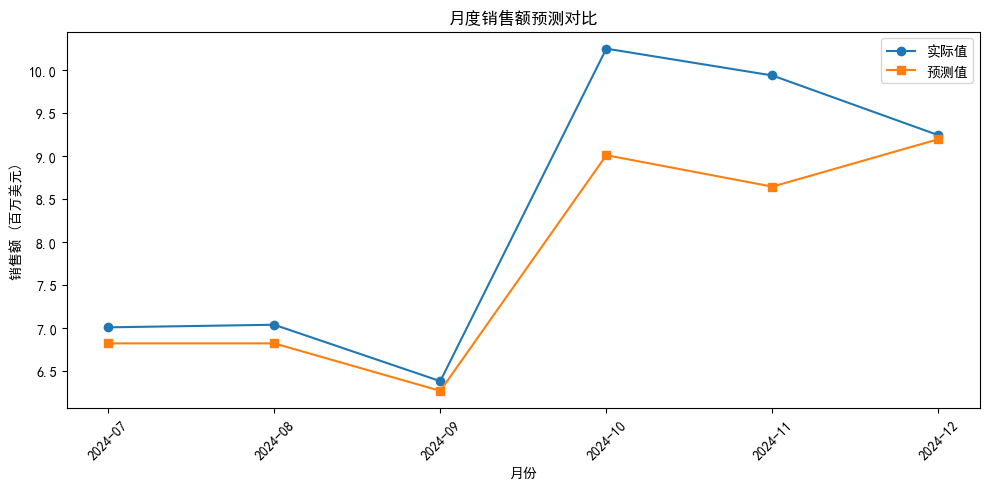

In [30]:
# 可视化对比
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# 全局设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 5))
plt.plot(test['order_month'], y_test_rev / 1_000_000, marker='o', label='实际值')
plt.plot(test['order_month'], pred_final / 1_000_000, marker='s', label='预测值')

plt.xticks(rotation=45)
plt.legend()
plt.title('月度销售额预测对比')
plt.ylabel('销售额 (百万美元)')
plt.xlabel('月份')
plt.tight_layout()
plt.show()

### data vis 2

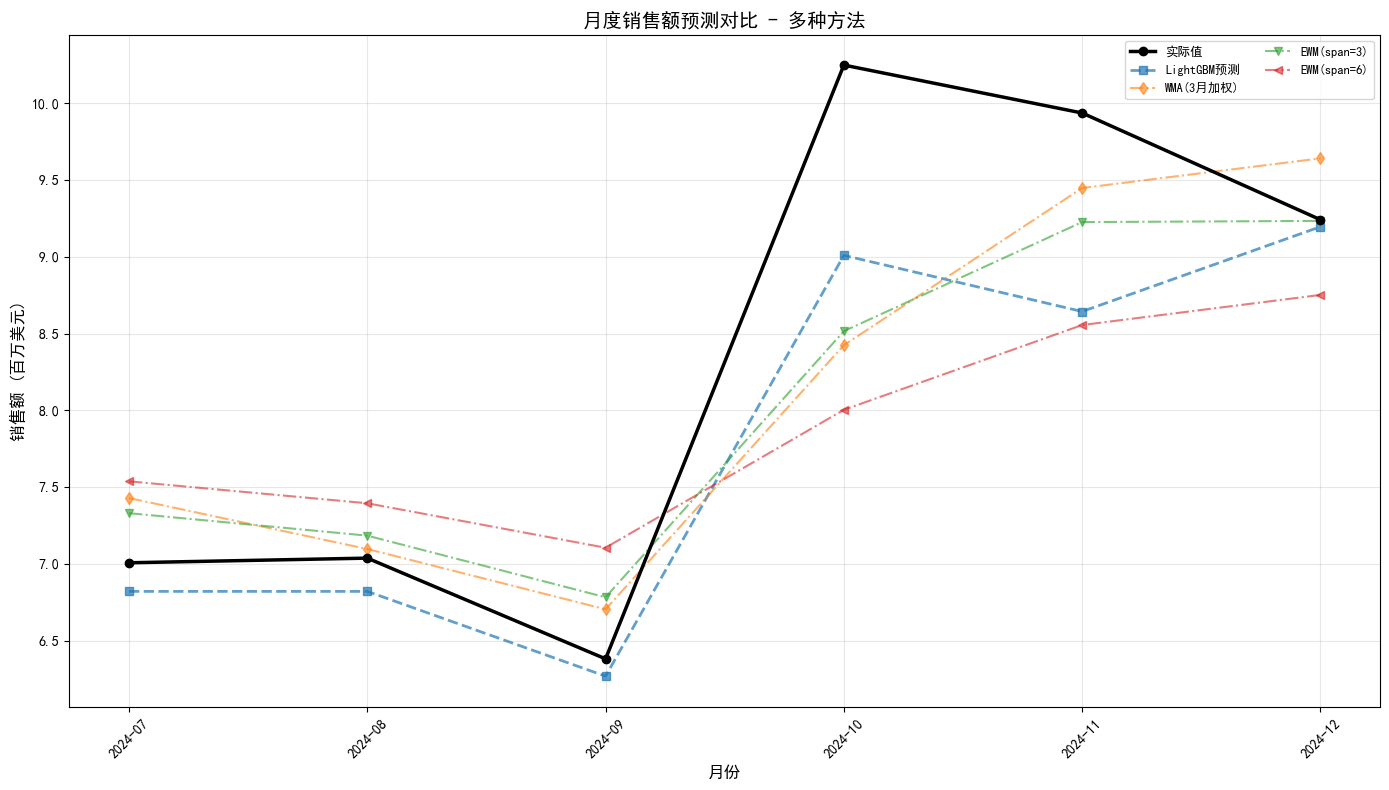

In [ ]:
# 可视化对比 - 包含多种 Baseline 方法
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# 全局设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 从 df_timeseries_features 中提取测试期间的数据
test_months = test['order_month'].values
baseline_data = df_timeseries_features[df_timeseries_features['order_month'].isin(test_months)].copy()
# 确保顺序一致
baseline_data = baseline_data.sort_values('order_month').reset_index(drop=True)

plt.figure(figsize=(14, 8))

# 实际值（粗线）
plt.plot(test['order_month'], y_test_rev / 1_000_000, 
         marker='o', label='实际值', linewidth=2.5, color='black', zorder=10)

# LightGBM 预测（原始和校准后）
plt.plot(test['order_month'], pred_final / 1_000_000, 
         marker='s', label='LightGBM预测', linewidth=2, alpha=0.7, linestyle='--')


# Baseline 方法组2: 加权平均
plt.plot(baseline_data['order_month'], baseline_data['wma_3'] / 1_000_000, 
         marker='d', label='WMA(3月加权)', alpha=0.6, linestyle='-.')
plt.plot(baseline_data['order_month'], baseline_data['ewm_3'] / 1_000_000, 
         marker='v', label='EWM(span=3)', alpha=0.6, linestyle='-.')
plt.plot(baseline_data['order_month'], baseline_data['ewm_6'] / 1_000_000, 
         marker='<', label='EWM(span=6)', alpha=0.6, linestyle='-.')

plt.xticks(rotation=45)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.title('月度销售额预测对比 - 多种方法', fontsize=14, fontweight='bold')
plt.ylabel('销售额 (百万美元)', fontsize=12)
plt.xlabel('月份', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### output the actual and predict results into a file

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

os.makedirs("output", exist_ok=True)

# 1) 先确保所有预测长度一致
assert len(test) == len(y_test_rev)
assert len(test) == len(np.asarray(lgm_pred_rev_final))
assert len(test) == len(np.asarray(cat_pred_rev))
assert len(test) == len(np.asarray(pred_final))

# 2) 取测试月份对应的 baseline
baseline_cols = [
    "rolling_3_month_avg",
    "rolling_6_month_avg",
    "wma_3",
    "ewm_3",
    "ewm_6",
]

baseline_data_test = (
    df_timeseries_features[
        df_timeseries_features["order_month"].isin(test["order_month"].astype(str).values)
    ]
    .sort_values("order_month")
    .reset_index(drop=True)
    [["order_month"] + baseline_cols]
    .copy()
)
baseline_data_test["order_month"] = baseline_data_test["order_month"].astype(str)

# 3) 构造主结果表
df_prediction_compare = pd.DataFrame({
    "order_month": test["order_month"].astype(str).values,
    "actual_monthly_revenue": y_test_rev.astype(float).values,
    "lightgbm_pred": np.asarray(lgm_pred_rev_final, dtype=float),
    "lightgbm_pred_calibrated": (
        np.asarray(lgm_pred_revenue_calibrated, dtype=float)
        if "lgm_pred_revenue_calibrated" in locals()
        else np.asarray(lgm_pred_rev_final, dtype=float)
    ),
    "catboost_pred": np.asarray(cat_pred_rev, dtype=float),
    "catboost_pred_calibrated": (
        np.asarray(cat_pred_rev_calibrated, dtype=float)
        if "cat_pred_rev_calibrated" in locals()
        else np.asarray(cat_pred_rev, dtype=float)
    ),
    "final_pred": np.asarray(pred_final, dtype=float),
})

# 4) 合并 baseline
df_prediction_compare = df_prediction_compare.merge(
    baseline_data_test,
    on="order_month",
    how="left"
)

# 5) 计算误差指标（每个模型都算一份）
df_prediction_compare["lightgbm_mae"] = (
    np.abs(df_prediction_compare["lightgbm_pred"] - df_prediction_compare["actual_monthly_revenue"])
)
df_prediction_compare["lightgbm_mape"] = (
    np.abs((df_prediction_compare["lightgbm_pred"] - df_prediction_compare["actual_monthly_revenue"])
           / df_prediction_compare["actual_monthly_revenue"].replace(0, np.nan))
)

df_prediction_compare["catboost_mae"] = (
    np.abs(df_prediction_compare["catboost_pred"] - df_prediction_compare["actual_monthly_revenue"])
)
df_prediction_compare["catboost_mape"] = (
    np.abs((df_prediction_compare["catboost_pred"] - df_prediction_compare["actual_monthly_revenue"])
           / df_prediction_compare["actual_monthly_revenue"].replace(0, np.nan))
)

df_prediction_compare["final_mae"] = (
    np.abs(df_prediction_compare["final_pred"] - df_prediction_compare["actual_monthly_revenue"])
)
df_prediction_compare["final_mape"] = (
    np.abs((df_prediction_compare["final_pred"] - df_prediction_compare["actual_monthly_revenue"])
           / df_prediction_compare["actual_monthly_revenue"].replace(0, np.nan))
)

# 7) 排序并预览
df_prediction_compare = df_prediction_compare.sort_values("order_month").reset_index(drop=True)
print(df_prediction_compare.head(10))

# 8) 导出 parquet
df_prediction_compare.to_parquet(
    "output/5-1-each_month_sale_amount_prediction_compare.parquet",
    index=False,engine='fastparquet'
)

print("已保存 parquet 文件: output/5-1-each_month_sale_amount_prediction_compare.parquet")
df_prediction_compare

  order_month  actual_monthly_revenue  lightgbm_pred  \
0     2024-07              7007342.21   6.820910e+06   
1     2024-08              7037587.62   6.820910e+06   
2     2024-09              6381304.00   6.268466e+06   
3     2024-10             10249693.14   9.010040e+06   
4     2024-11              9937478.48   8.644162e+06   
5     2024-12              9242308.80   9.196607e+06   

   lightgbm_pred_calibrated  catboost_pred  catboost_pred_calibrated  \
0              6.820915e+06   9.970086e+06              9.970086e+06   
1              6.820915e+06   9.335860e+06              9.335860e+06   
2              6.268471e+06   9.500040e+06              9.500040e+06   
3              9.010045e+06   9.007949e+06              9.007949e+06   
4              8.644167e+06   1.050338e+07              1.050338e+07   
5              9.196612e+06   9.950616e+06              9.950616e+06   

     final_pred  rolling_3_month_avg  rolling_6_month_avg         wma_3  \
0  6.820910e+06         8.0

,order_month,actual_monthly_revenue,lightgbm_pred,lightgbm_pred_calibrated,catboost_pred,catboost_pred_calibrated,final_pred,rolling_3_month_avg,rolling_6_month_avg,wma_3,ewm_3,ewm_6,lightgbm_mae,lightgbm_mape,catboost_mae,catboost_mape,final_mae,final_mape
0,2024-07,7007342.21,6.820910e+06,6.820915e+06,9.970086e+06,9.970086e+06,6.820910e+06,8.065133e+06,6.651410e+06,7.428869e+06,7.330476e+06,7.537943e+06,1.864320e+05,0.026605,2.962744e+06,0.422806,1.864320e+05,0.026605
1,2024-08,7037587.62,6.820910e+06,6.820915e+06,9.335860e+06,9.335860e+06,6.820910e+06,7.701132e+06,6.919377e+06,7.097097e+06,7.184032e+06,7.394984e+06,2.166775e+05,0.030789,2.298272e+06,0.326571,2.166775e+05,0.030789
2,2024-09,6381304.00,6.268466e+06,6.268471e+06,9.500040e+06,9.500040e+06,6.268466e+06,7.166688e+06,7.209879e+06,6.704405e+06,6.782668e+06,7.105361e+06,1.128385e+05,0.017683,3.118736e+06,0.488730,1.128385e+05,0.017683
3,2024-10,10249693.14,9.010040e+06,9.010045e+06,9.007949e+06,9.007949e+06,9.010040e+06,6.808745e+06,7.436939e+06,8.424879e+06,8.516181e+06,8.003742e+06,1.239653e+06,0.120945,1.241744e+06,0.121149,1.239653e+06,0.120945
4,2024-11,9937478.48,8.644162e+06,8.644167e+06,1.050338e+07,1.050338e+07,8.644162e+06,7.889528e+06,7.795330e+06,9.448854e+06,9.226830e+06,8.556238e+06,1.293316e+06,0.130145,5.658990e+05,0.056946,1.293316e+06,0.130145
5,2024-12,9242308.80,9.196607e+06,9.196612e+06,9.950616e+06,9.950616e+06,9.196607e+06,8.856159e+06,8.011423e+06,9.641929e+06,9.234569e+06,8.752258e+06,4.570179e+04,0.004945,7.083073e+05,0.076637,4.570179e+04,0.004945


In [1]:
import gc

gc.collect()

31

In [ ]:
# 关闭数据库连接
engine.dispose()